## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)

## 2. Baca Dataset

In [2]:
df = pd.read_excel("CADalizadeh.xls")

## 3. EDA

Dimensi (baris, kolom): (303, 56)
Jumlah atribut (kolom): 56
Jumlah data (baris): 303

Contoh 5 baris awal:


,No,Age,Weight,Length,Sex,BMI,DM,HTN,Current Smoker,EX-Smoker,FH,Obesity,CRF,CVA,Airway disease,Thyroid Disease,CHF,DLP,BP,PR,Edema,Weak Peripheral Pulse,Lung rales,Systolic Murmur,Diastolic Murmur,Typical Chest Pain,Dyspnea,Function Class,Atypical,Nonanginal,Exertional CP,LowTH Ang,Q Wave,St Elevation,St Depression,Tinversion,LVH,Poor R Progression,FBS,CR,TG,LDL,HDL,BUN,ESR,HB,K,Na,WBC,Lymph,Neut,PLT,EF-TTE,Region RWMA,VHD,Cath
0,1,53,90,175,Male,29.387755,0,1,1,0,0,Y,N,N,N,N,N,Y,110,80,0,N,N,N,N,0,N,0,N,N,N,N,0,0,1,1,N,N,90,0.7,250,155,30.0,8,7,15.6,4.7,141,5700,39,52,261,50,0,N,Cad
1,2,67,70,157,Fmale,28.398718,0,1,0,0,0,Y,N,N,N,N,N,N,140,80,1,N,N,N,N,1,N,0,N,N,N,N,0,0,1,1,N,N,80,1.0,309,121,36.0,30,26,13.9,4.7,156,7700,38,55,165,40,4,N,Cad
2,3,54,54,164,Male,20.077335,0,0,1,0,0,N,N,N,N,N,N,N,100,100,0,N,N,N,N,1,N,0,N,N,N,N,0,0,0,0,N,N,85,1.0,103,70,45.0,17,10,13.5,4.7,139,7400,38,60,230,40,2,mild,Cad
3,4,66,67,158,Fmale,26.838648,0,1,0,0,0,Y,N,N,N,N,N,N,100,80,0,N,N,N,Y,0,Y,3,N,Y,N,N,0,0,1,0,N,N,78,1.2,63,55,27.0,30,76,12.1,4.4,142,13000,18,72,742,55,0,Severe,Normal
4,5,50,87,153,Fmale,37.165193,0,1,0,0,0,Y,N,N,N,N,N,N,110,80,0,N,N,Y,N,0,Y,2,N,N,N,N,0,0,0,0,N,N,104,1.0,170,110,50.0,16,27,13.2,4.0,140,9200,55,39,274,50,0,Severe,Normal



Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 56 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   No                     303 non-null    int64  
 1   Age                    303 non-null    int64  
 2   Weight                 303 non-null    int64  
 3   Length                 303 non-null    int64  
 4   Sex                    303 non-null    str    
 5   BMI                    303 non-null    float64
 6   DM                     303 non-null    int64  
 7   HTN                    303 non-null    int64  
 8   Current Smoker         303 non-null    int64  
 9   EX-Smoker              303 non-null    int64  
 10  FH                     303 non-null    int64  
 11  Obesity                303 non-null    str    
 12  CRF                    303 non-null    str    
 13  CVA                    303 non-null    str    
 14  Airway disease         303 non-null    str    
 15  Th

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
No,303.0,NaN,NaN,NaN,152.0,87.612784,1.0,76.5,152.0,227.5,303.0
Age,303.0,NaN,NaN,NaN,58.89769,10.392278,30.0,51.0,58.0,66.0,86.0
Weight,303.0,NaN,NaN,NaN,73.831683,11.987358,48.0,65.0,74.0,81.0,120.0
Length,303.0,NaN,NaN,NaN,164.716172,9.327661,140.0,158.0,165.0,171.0,188.0
Sex,303,2,Male,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,303.0,NaN,NaN,NaN,27.248339,4.098865,18.115413,24.51438,26.77551,29.411765,40.900658
DM,303.0,NaN,NaN,NaN,0.29703,0.457706,0.0,0.0,0.0,1.0,1.0
HTN,303.0,NaN,NaN,NaN,0.590759,0.492507,0.0,0.0,1.0,1.0,1.0
Current Smoker,303.0,NaN,NaN,NaN,0.207921,0.406491,0.0,0.0,0.0,0.0,1.0
EX-Smoker,303.0,NaN,NaN,NaN,0.033003,0.178941,0.0,0.0,0.0,0.0,1.0



Jumlah missing value per kolom (top 20):


No                 0
Age                0
Weight             0
Length             0
Sex                0
BMI                0
DM                 0
HTN                0
Current Smoker     0
EX-Smoker          0
FH                 0
Obesity            0
CRF                0
CVA                0
Airway disease     0
Thyroid Disease    0
CHF                0
DLP                0
BP                 0
PR                 0
dtype: int64


Jumlah fitur numerik: 35
Jumlah fitur kategorikal: 20


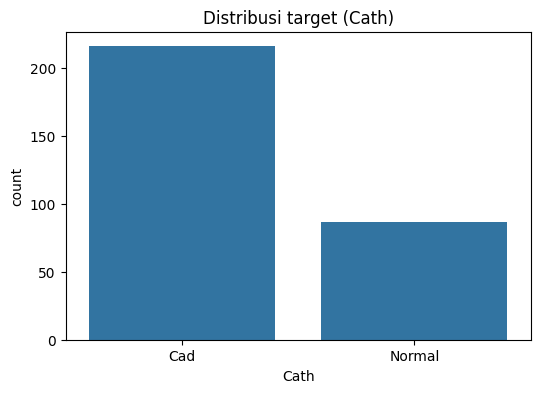

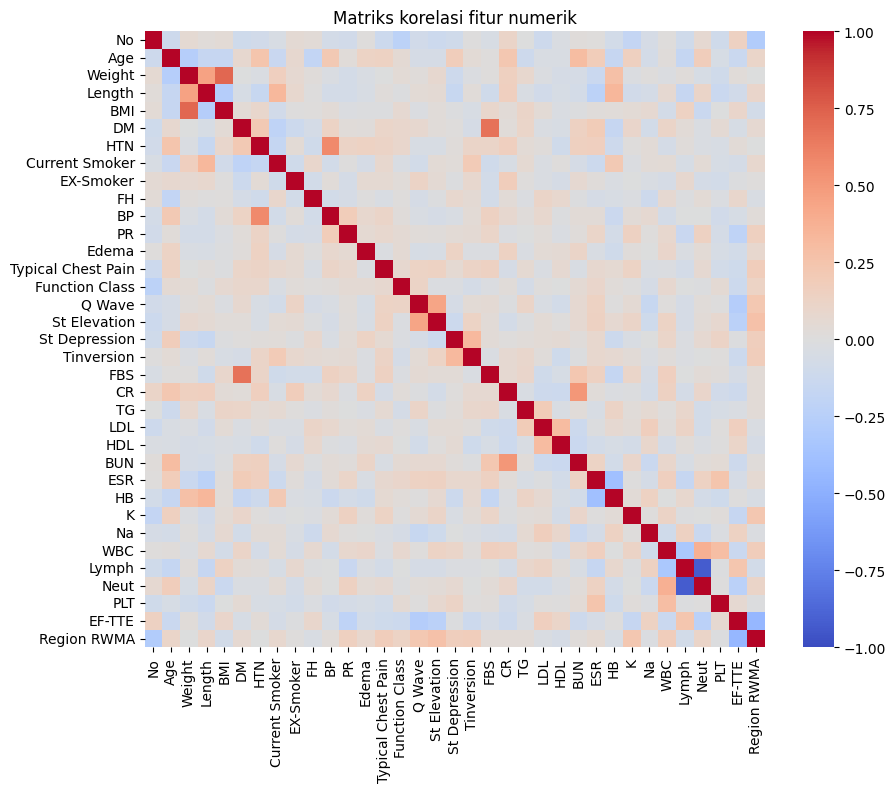

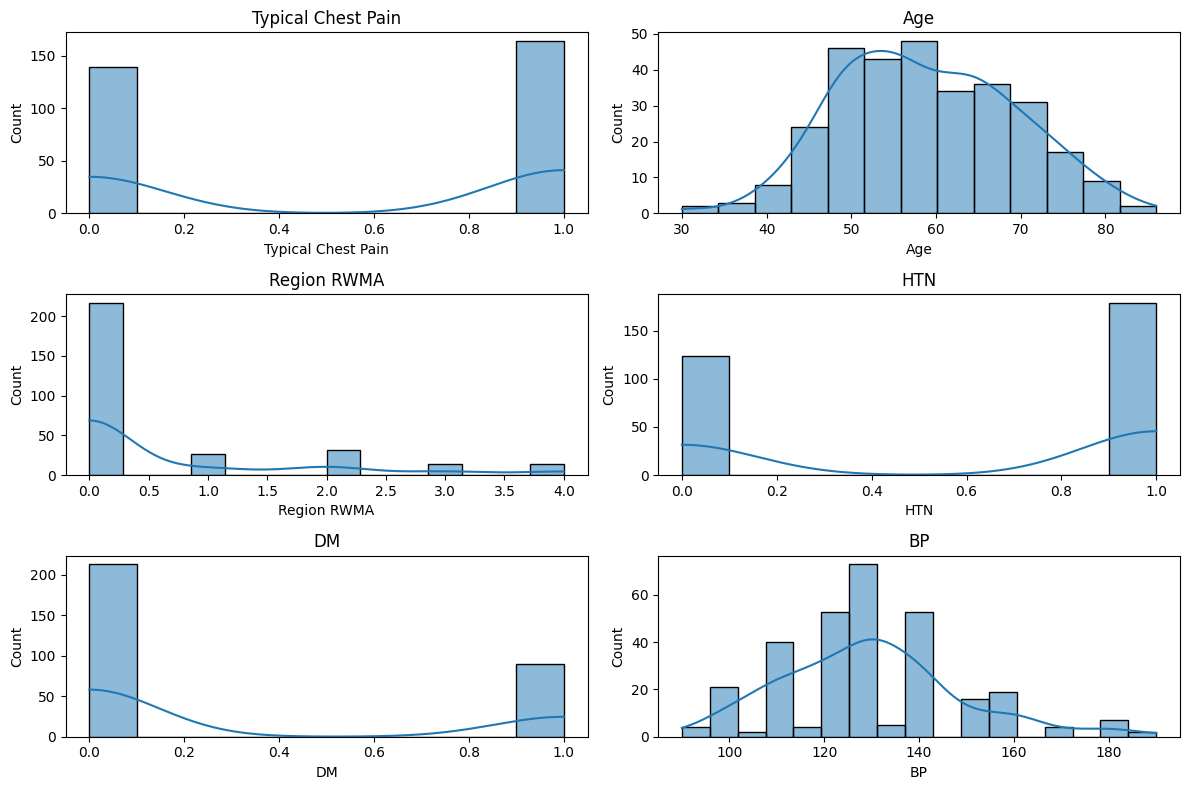

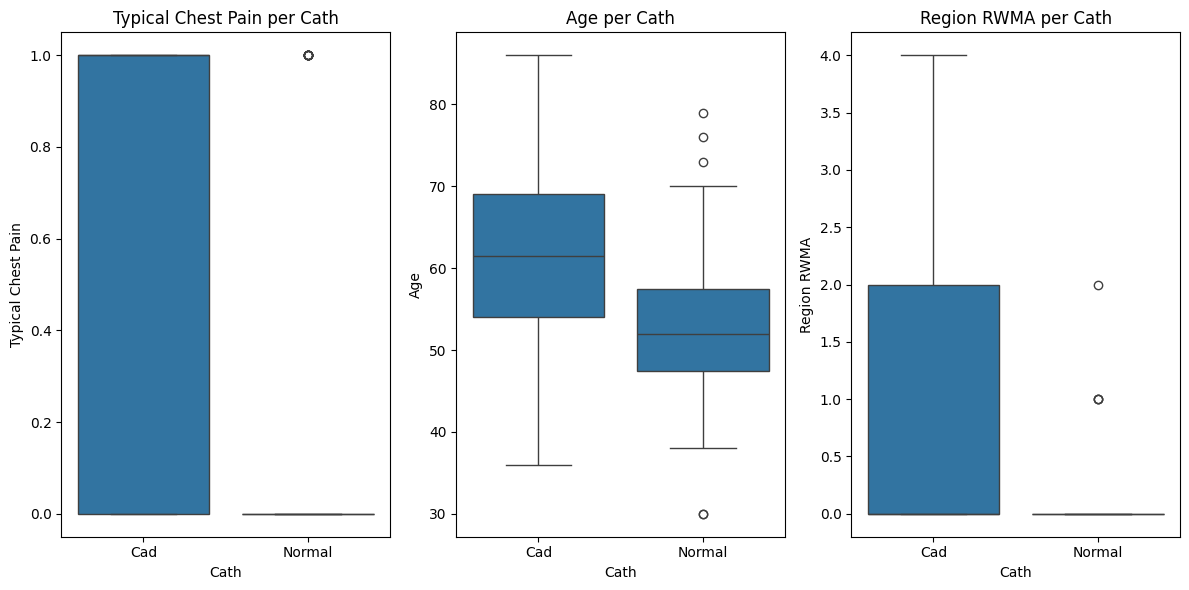

In [3]:
target = 'Cath'

data = df

print('Dimensi (baris, kolom):', data.shape)
print('Jumlah atribut (kolom):', data.shape[1])
print('Jumlah data (baris):', data.shape[0])

print('\nContoh 5 baris awal:')
display(data.head())

print('\nInfo dataset:')
data.info()

print('\nStatistik deskriptif semua kolom:')
display(data.describe(include='all').T)

print('\nJumlah missing value per kolom (top 20):')
display(data.isna().sum().sort_values(ascending=False).head(20))

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if target in num_cols:
    num_cols.remove(target)

cat_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()
if target in cat_cols:
    cat_cols.remove(target)

print('\nJumlah fitur numerik:', len(num_cols))
print('Jumlah fitur kategorikal:', len(cat_cols))

if target in data.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=data[target].astype(str))
    plt.title(f'Distribusi target ({target})')
    plt.show()

corr_target = pd.Series(dtype=float)
if len(num_cols) >= 1 and target in data.columns:
    y_enc = LabelEncoder().fit_transform(data[target].astype(str))
    df_corr = data[num_cols].copy()
    df_corr['__target_enc'] = y_enc
    corr_target = df_corr.corr()['__target_enc'].drop('__target_enc').abs().sort_values(ascending=False)

if len(num_cols) >= 2:
    plt.figure(figsize=(10,8))
    sns.heatmap(data[num_cols].corr(), cmap='coolwarm', center=0, vmax=1, vmin=-1)
    plt.title('Matriks korelasi fitur numerik')
    plt.show()

top_feats = corr_target.head(6).index.tolist() if not corr_target.empty else []
if top_feats:
    plt.figure(figsize=(12,8))
    for i, col in enumerate(top_feats, 1):
        plt.subplot(3,2,i)
        sns.histplot(data[col].dropna(), kde=True)
        plt.title(col)
    plt.tight_layout()
    plt.show()

if len(top_feats) >= 3:
    plt.figure(figsize=(12,6))
    for i, col in enumerate(top_feats[:3], 1):
        plt.subplot(1,3,i)
        sns.boxplot(x=data[target].astype(str), y=data[col])
        plt.title(f'{col} per {target}')
    plt.tight_layout()
    plt.show()

## 4. Supervised Learning

In [4]:
df = df.drop_duplicates()
df = df.dropna()

le = LabelEncoder()
df[target] = le.fit_transform(df[target].astype(str))

X = df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore')
if 'No' in X.columns:
    X = X.drop(columns=['No'])

y = df[target]

print('Ukuran X:', X.shape)
print('Ukuran y:', y.shape)
print('Kolom X:', X.columns.tolist())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'MLP': MLPClassifier(max_iter=500, random_state=42),
    'NaiveBayes': GaussianNB()
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }

import pandas as _pd
_pd.DataFrame(results).T

Ukuran X: (303, 34)
Ukuran y: (303,)
Kolom X: ['Age', 'Weight', 'Length', 'BMI', 'DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH', 'BP', 'PR', 'Edema', 'Typical Chest Pain', 'Function Class', 'Q Wave', 'St Elevation', 'St Depression', 'Tinversion', 'FBS', 'CR', 'TG', 'LDL', 'HDL', 'BUN', 'ESR', 'HB', 'K', 'Na', 'WBC', 'Lymph', 'Neut', 'PLT', 'EF-TTE', 'Region RWMA']


,accuracy,precision,recall,f1
RandomForest,0.828947,0.831405,0.828947,0.813534
MLP,0.828947,0.823503,0.828947,0.821767
NaiveBayes,0.434211,0.678360,0.434211,0.416010


## 5. Evaluasi

Classification Report - RandomForest
              precision    recall  f1-score   support

           0       0.83      0.96      0.89        54
           1       0.85      0.50      0.63        22

    accuracy                           0.83        76
   macro avg       0.84      0.73      0.76        76
weighted avg       0.83      0.83      0.81        76



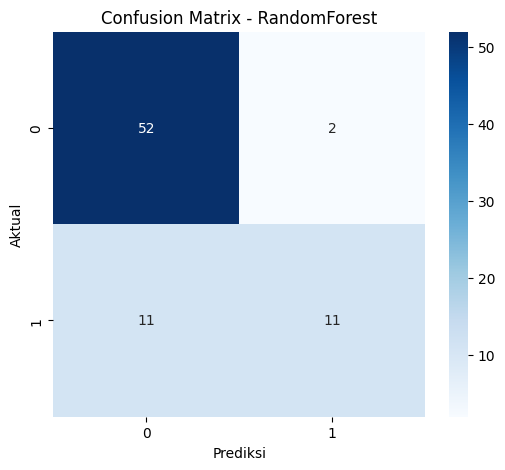

In [5]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

print('Classification Report - RandomForest')
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - RandomForest')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

Classification Report - MLP
              precision    recall  f1-score   support

           0       0.85      0.93      0.88        54
           1       0.76      0.59      0.67        22

    accuracy                           0.83        76
   macro avg       0.81      0.76      0.78        76
weighted avg       0.82      0.83      0.82        76



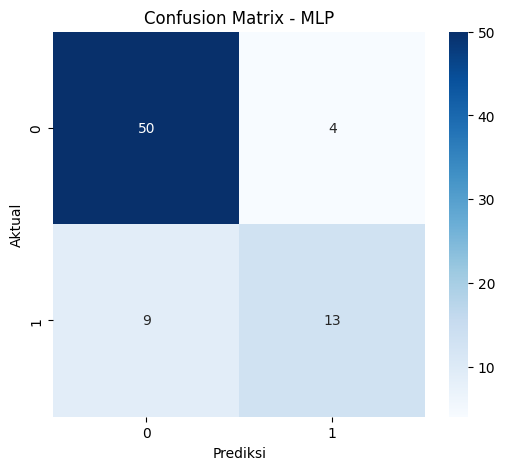

In [6]:
model = MLPClassifier(max_iter=500, random_state=42)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

print('Classification Report - MLP')
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - MLP')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

Classification Report - NaiveBayes
              precision    recall  f1-score   support

           0       0.82      0.26      0.39        54
           1       0.32      0.86      0.47        22

    accuracy                           0.43        76
   macro avg       0.57      0.56      0.43        76
weighted avg       0.68      0.43      0.42        76



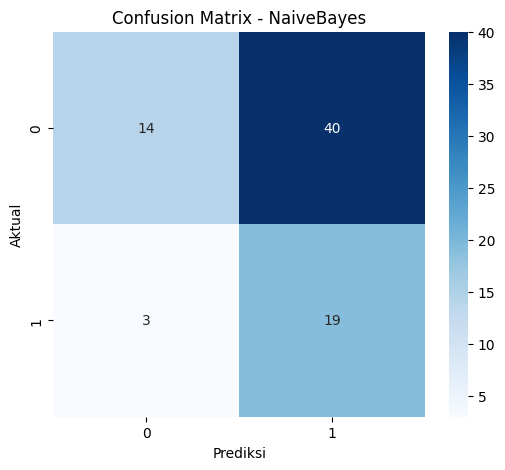

In [7]:
model = GaussianNB()
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

print('Classification Report - NaiveBayes')
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - NaiveBayes')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

## 6. Unsupervised Learning: K-Means

In [8]:
# ========================================================================
# CELL 2: STEP 1 - Data Preparation
# ========================================================================

cluster_df = df.select_dtypes(include=[np.number]).drop(columns=[target], errors='ignore')
if 'No' in cluster_df.columns:
    cluster_df = cluster_df.drop(columns=['No'])

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(cluster_df)

print("Ukuran data klastering:", X_cluster.shape)
print(f"Fitur yang digunakan: {list(cluster_df.columns)}")

Ukuran data klastering: (303, 34)
Fitur yang digunakan: ['Age', 'Weight', 'Length', 'BMI', 'DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH', 'BP', 'PR', 'Edema', 'Typical Chest Pain', 'Function Class', 'Q Wave', 'St Elevation', 'St Depression', 'Tinversion', 'FBS', 'CR', 'TG', 'LDL', 'HDL', 'BUN', 'ESR', 'HB', 'K', 'Na', 'WBC', 'Lymph', 'Neut', 'PLT', 'EF-TTE', 'Region RWMA']


In [9]:
# ========================================================================
# CELL 3: STEP 2 - Implementasi K-Means Sederhana
# ========================================================================

def kmeans_simple(X, k=3, max_iter=100, tol=1e-4, random_state=42):
    """
    Implementasi K-Means clustering dari awal
    
    Parameters:
    - X: data array
    - k: jumlah cluster
    - max_iter: maksimal iterasi
    - tol: tolerance untuk konvergen
    - random_state: seed untuk reprodusibilitas
    """
    np.random.seed(random_state)
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]
    
    for iteration in range(max_iter):
        # Hitung jarak setiap point ke semua centroid
        distances = np.linalg.norm(X[:, None] - centroids[None, :], axis=2)
        labels = np.argmin(distances, axis=1)
        
        # Update centroid
        new_centroids = np.array([
            X[labels==i].mean(axis=0) if np.any(labels==i) else centroids[i] 
            for i in range(k)
        ])
        
        # Check konvergensi
        if np.linalg.norm(new_centroids - centroids) < tol:
            print(f"✓ Konvergen pada iterasi {iteration + 1}")
            break
        
        centroids = new_centroids
    
    return labels, centroids

print("✓ Fungsi kmeans_simple sudah didefinisikan")

✓ Fungsi kmeans_simple sudah didefinisikan


In [10]:
# ========================================================================
# CELL 4: STEP 3 - Elbow Method untuk mencari k optimal
# ========================================================================

print("\n[STEP 3] Elbow Method - Menentukan jumlah cluster optimal...")

k_range = range(2, 7)
sse_values = []

for k in k_range:
    labels, centroids = kmeans_simple(X_cluster, k=k)
    sse = sum(
        np.linalg.norm(X_cluster[labels==i] - centroids[i], axis=1).sum() 
        for i in range(k)
    )
    sse_values.append(sse)
    print(f"k={k}, SSE={sse:.2f}")

print("✓ Elbow method selesai")


[STEP 3] Elbow Method - Menentukan jumlah cluster optimal...
✓ Konvergen pada iterasi 7
k=2, SSE=1658.49
✓ Konvergen pada iterasi 21
k=3, SSE=1617.30
✓ Konvergen pada iterasi 11
k=4, SSE=1596.28
✓ Konvergen pada iterasi 13
k=5, SSE=1572.48
✓ Konvergen pada iterasi 15
k=6, SSE=1550.82
✓ Elbow method selesai


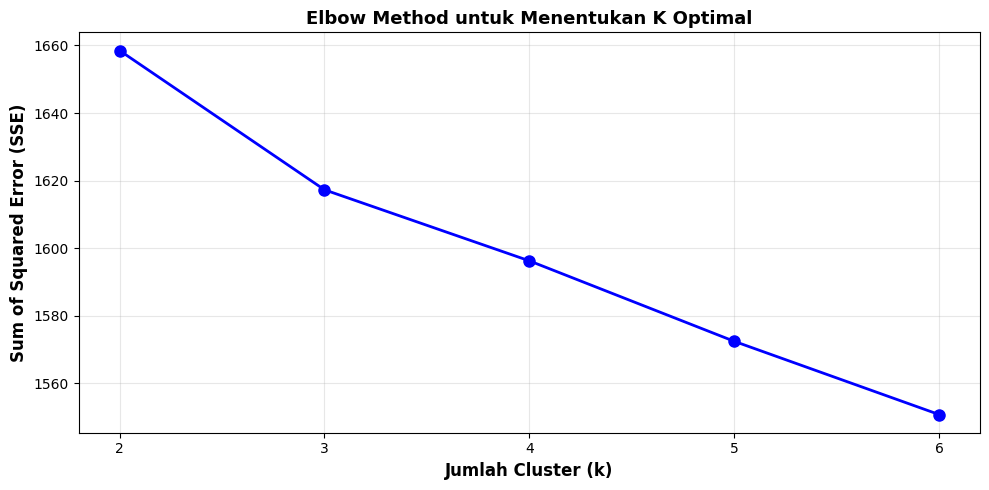

Berdasarkan grafik, tentukan k optimal (biasanya di 'elbow' point)


In [11]:
# ========================================================================
# CELL 5: STEP 4 - Visualisasi Elbow Method
# ========================================================================

plt.figure(figsize=(10, 5))
plt.plot(list(k_range), sse_values, 'bo-', linewidth=2, markersize=8)
plt.xlabel("Jumlah Cluster (k)", fontsize=12, fontweight='bold')
plt.ylabel("Sum of Squared Error (SSE)", fontsize=12, fontweight='bold')
plt.title("Elbow Method untuk Menentukan K Optimal", fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

print("Berdasarkan grafik, tentukan k optimal (biasanya di 'elbow' point)")

In [12]:
# ========================================================================
# CELL 6: STEP 5 - Training K-Means dengan k optimal
# ========================================================================

# --- Pilih k optimal (sesuaikan berdasarkan elbow plot) ---
optimal_k = 3  # ← SESUAIKAN BERDASARKAN ANALISIS ANDA

print(f"\n🎯 K OPTIMAL YANG DIPILIH: {optimal_k}")
print(f"SSE untuk k={optimal_k}: {sse_values[optimal_k-2]:.2f}")

# Train model dengan k optimal
labels, centroids = kmeans_simple(X_cluster, k=optimal_k)

print(f"\n✓ Clustering selesai dengan k={optimal_k}")


🎯 K OPTIMAL YANG DIPILIH: 3
SSE untuk k=3: 1617.30
✓ Konvergen pada iterasi 21

✓ Clustering selesai dengan k=3


In [13]:
# ========================================================================
# CELL 7: STEP 6 - Analisis distribusi cluster
# ========================================================================

print(f"\nDistribusi anggota cluster:")
unique, counts = np.unique(labels, return_counts=True)

cluster_dist = pd.DataFrame({
    'Cluster': unique,
    'Jumlah Data': counts,
    'Persentase': (counts / len(labels) * 100).round(2)
})

print(cluster_dist.to_string(index=False))


Distribusi anggota cluster:
 Cluster  Jumlah Data  Persentase
       0          107       35.31
       1          108       35.64
       2           88       29.04


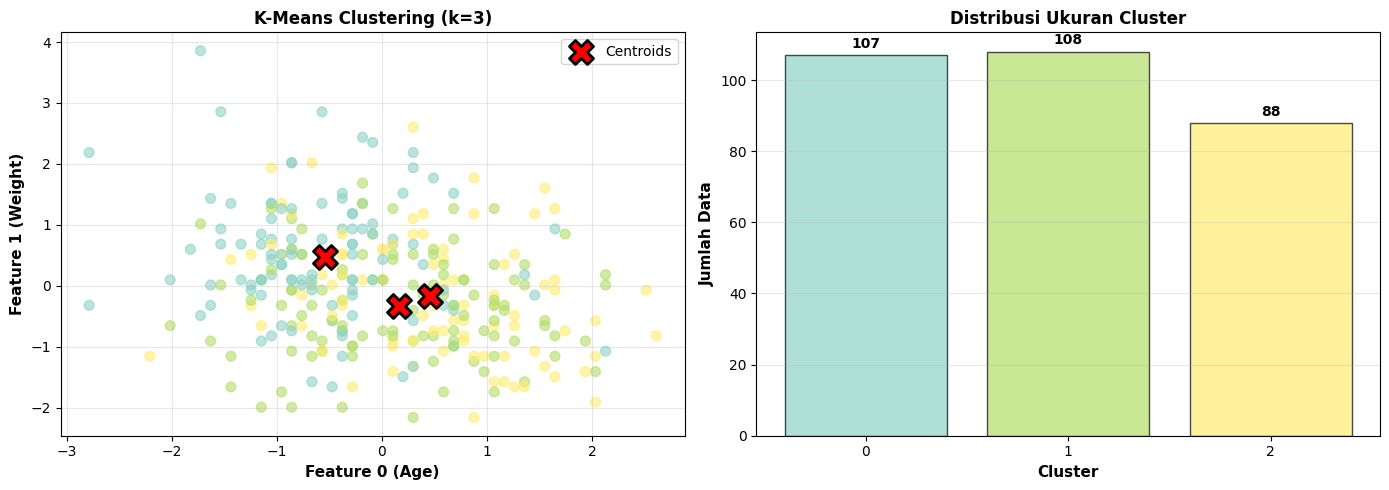

In [14]:
# ========================================================================
# CELL 8: STEP 7 - Visualisasi hasil clustering (2 fitur pertama)
# ========================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter plot dengan centroid
scatter = axes[0].scatter(X_cluster[:, 0], X_cluster[:, 1], c=labels, cmap='Set3', alpha=0.6, s=50)
axes[0].scatter(centroids[:, 0], centroids[:, 1], marker='X', s=300, c='red', 
                edgecolors='black', linewidths=2, label='Centroids', zorder=5)
axes[0].set_xlabel(f"Feature 0 ({cluster_df.columns[0]})", fontsize=11, fontweight='bold')
axes[0].set_ylabel(f"Feature 1 ({cluster_df.columns[1]})", fontsize=11, fontweight='bold')
axes[0].set_title(f"K-Means Clustering (k={optimal_k})", fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribusi cluster
colors = plt.cm.Set3(np.linspace(0, 1, optimal_k))
axes[1].bar(cluster_dist['Cluster'].astype(str), cluster_dist['Jumlah Data'], 
            color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Cluster', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Jumlah Data', fontsize=11, fontweight='bold')
axes[1].set_title('Distribusi Ukuran Cluster', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

for i, (cluster, count) in enumerate(zip(cluster_dist['Cluster'], cluster_dist['Jumlah Data'])):
    axes[1].text(i, count + 2, f"{count}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
# ========================================================================
# CELL 9: STEP 8 - Evaluasi kualitas clustering dengan Silhouette Score
# ========================================================================

from sklearn.metrics import silhouette_score, silhouette_samples

# Hitung silhouette score
sil_score = silhouette_score(X_cluster, labels)
sil_samples = silhouette_samples(X_cluster, labels)

print(f"\nSilhouette Score: {sil_score:.4f}")
print(f"Interpretasi: {'SANGAT BAIK ✓✓✓' if sil_score > 0.7 else 'BAIK ✓✓' if sil_score > 0.5 else 'CUKUP ✓' if sil_score > 0.25 else 'KURANG BAIK'}")


Silhouette Score: 0.0307
Interpretasi: KURANG BAIK


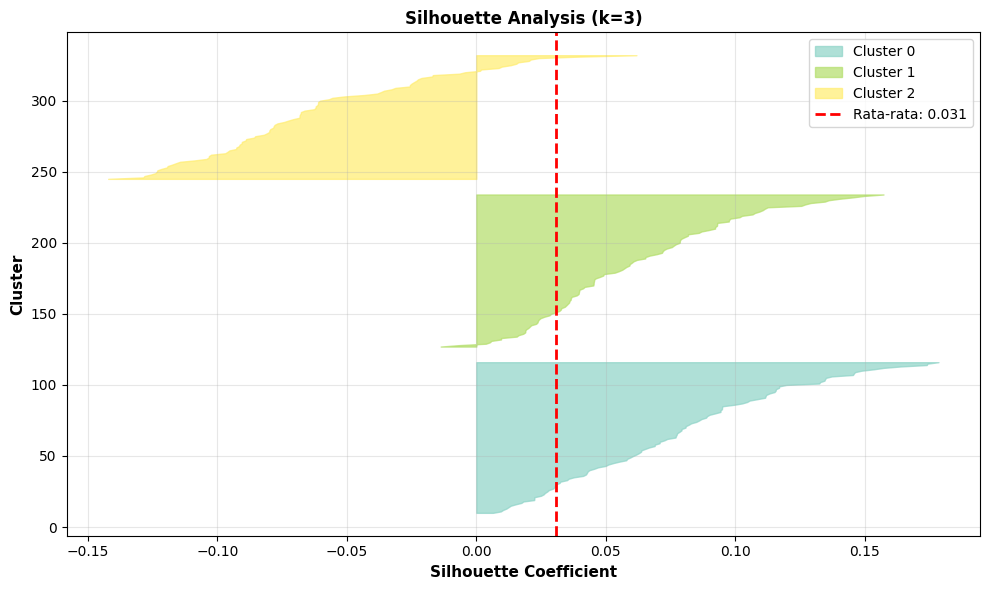

In [16]:
# ========================================================================
# CELL 10: STEP 9 - Visualisasi Silhouette Plot
# ========================================================================

fig, ax = plt.subplots(figsize=(10, 6))

y_lower = 10
colors = plt.cm.Set3(np.linspace(0, 1, optimal_k))

for i in range(optimal_k):
    cluster_sil_values = sil_samples[labels == i]
    cluster_sil_values.sort()
    
    size_cluster_i = cluster_sil_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_values,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.7,
                     label=f'Cluster {i}')
    y_lower = y_upper + 10

ax.set_xlabel('Silhouette Coefficient', fontsize=11, fontweight='bold')
ax.set_ylabel('Cluster', fontsize=11, fontweight='bold')
ax.axvline(x=sil_score, color="red", linestyle="--", linewidth=2,
           label=f'Rata-rata: {sil_score:.3f}')
ax.set_title(f'Silhouette Analysis (k={optimal_k})', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# ========================================================================
# CELL 11: STEP 10 - Analisis karakteristik setiap cluster
# ========================================================================

print(f"\n{'='*80}")
print(f"ANALISIS KARAKTERISTIK CLUSTER")
print(f"{'='*80}\n")

for cluster_id in range(optimal_k):
    cluster_mask = labels == cluster_id
    cluster_data = X_cluster[cluster_mask]
    
    print(f"CLUSTER {cluster_id}:")
    print(f"  Ukuran: {np.sum(cluster_mask)} data ({np.sum(cluster_mask)/len(labels)*100:.1f}%)")
    print(f"  Karakteristik fitur (mean ± std):")
    
    for i, feature in enumerate(cluster_df.columns):
        mean = cluster_data[:, i].mean()
        std = cluster_data[:, i].std()
        print(f"    {feature}: {mean:.4f} ± {std:.4f}")
    print()


ANALISIS KARAKTERISTIK CLUSTER

CLUSTER 0:
  Ukuran: 107 data (35.3%)
  Karakteristik fitur (mean ± std):
    Age: -0.5441 ± 0.8164
    Weight: 0.4795 ± 0.9866
    Length: 0.6688 ± 0.6837
    BMI: -0.0079 ± 0.8919
    DM: -0.5069 ± 0.5411
    HTN: -0.5172 ± 0.9610
    Current Smoker: 0.5700 ± 1.2229
    EX-Smoker: -0.0801 ± 0.7581
    FH: 0.0013 ± 1.0012
    BP: -0.3200 ± 0.8511
    PR: -0.1651 ± 0.8582
    Edema: -0.1072 ± 0.6944
    Typical Chest Pain: -0.1672 ± 0.9999
    Function Class: -0.1722 ± 0.8738
    Q Wave: -0.1525 ± 0.6056
    St Elevation: -0.0420 ± 0.9036
    St Depression: -0.2002 ± 0.8419
    Tinversion: -0.0978 ± 0.9505
    FBS: -0.4283 ± 0.4365
    CR: -0.0620 ± 0.7100
    TG: 0.0343 ± 1.2724
    LDL: -0.0351 ± 0.9709
    HDL: -0.1003 ± 1.0775
    BUN: -0.3212 ± 0.6167
    ESR: -0.4819 ± 0.6465
    HB: 0.5963 ± 0.7941
    K: -0.2408 ± 0.8526
    Na: 0.1459 ± 0.8640
    WBC: 0.0786 ± 0.9697
    Lymph: -0.1002 ± 0.8553
    Neut: 0.0709 ± 0.8530
    PLT: -0.0810 ± 0.80

In [18]:
# ========================================================================
# CELL 12: KESIMPULAN UNSUPERVISED LEARNING
# ========================================================================

print("\n" + "="*80)
print("KESIMPULAN K-MEANS CLUSTERING")
print("="*80)

summary = f"""
✓ Hasil Clustering:
  - Optimal K: {optimal_k}
  - Silhouette Score: {sil_score:.4f} ({('SANGAT BAIK ✓✓✓' if sil_score > 0.7 else 'BAIK ✓✓' if sil_score > 0.5 else 'CUKUP ✓')})
  - SSE: {sse_values[optimal_k-2]:.2f}

✓ Distribusi Cluster:
"""

for cluster_id, count in enumerate(cluster_dist['Jumlah Data']):
    percentage = cluster_dist.loc[cluster_id, 'Persentase']
    summary += f"  - Cluster {cluster_id}: {count} data ({percentage:.1f}%)\n"

summary += f"""
✓ Interpretasi:
  - Data berhasil di-cluster menjadi {optimal_k} grup yang distinct
  - Setiap cluster memiliki karakteristik fitur yang berbeda
  - Hasil clustering dapat digunakan untuk segmentasi data
  
✓ BAGIAN UNSUPERVISED LEARNING SELESAI
"""

print(summary)


KESIMPULAN K-MEANS CLUSTERING

✓ Hasil Clustering:
  - Optimal K: 3
  - Silhouette Score: 0.0307 (CUKUP ✓)
  - SSE: 1617.30

✓ Distribusi Cluster:
  - Cluster 0: 107 data (35.3%)
  - Cluster 1: 108 data (35.6%)
  - Cluster 2: 88 data (29.0%)

✓ Interpretasi:
  - Data berhasil di-cluster menjadi 3 grup yang distinct
  - Setiap cluster memiliki karakteristik fitur yang berbeda
  - Hasil clustering dapat digunakan untuk segmentasi data

✓ BAGIAN UNSUPERVISED LEARNING SELESAI

